# Importance Sampling for AR(1) Neural Posterior Estimation

**Comparison: Uniform ($\alpha=1.0$) vs IS with $\text{Beta}(0.8, 0.8)$ proposal ($\alpha=0.8$)**

AR(1) model: $X_t = \rho X_{t-1} + \varepsilon_t$, $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$

Priors: $\rho \sim U(-1,1)$, $\sigma \sim U(0,5)$. Observed: $T=64$ time steps.

The IS proposal replaces the uniform prior with $\text{Beta}(\alpha,\alpha)$ for $\rho$ and $\text{Beta}(\alpha, 1)$ for $\sigma$. Training uses the unnormalised IS loss:
$$\hat{L}^{\text{IS}}(\phi) = \frac{1}{N}\sum_{i=1}^N w(\theta_i)\,\lVert f_\phi(x_i) - \theta_i \rVert^2, \quad w(\theta) = \frac{p(\theta)}{q_\alpha(\theta)}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import torch
import torch.nn as nn
from sbi import GRUEstimator, train, simulate_ar1_batch

plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

# --- Config ---
A = 5.0
T = 64
N_EPOCHS = 128
N_BATCHES = 128
BATCH_SIZE = 128
LR = 2e-3
N_SEEDS = 5
ALPHA = 0.8  # IS proposal parameter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# --- Model ---
class AR1Estimator(GRUEstimator):
    def alter_outputs(self, x):
        rho = torch.tanh(x[:, 0])
        sigma = torch.exp(x[:, 1])
        return torch.stack([rho, sigma], dim=1)

# --- Samplers ---
def sample_uniform(batch_size):
    rho = torch.empty(batch_size).uniform_(-1, 1)
    sigma = torch.empty(batch_size).uniform_(0, A)
    x = simulate_ar1_batch(rho, sigma, T)
    return torch.stack([rho, sigma], dim=1), x

def sample_is(batch_size, alpha=ALPHA):
    rho_tilde = np.random.beta(alpha, alpha, size=batch_size)
    sigma_tilde = np.random.beta(alpha, 1.0, size=batch_size)
    rho = torch.tensor(2 * rho_tilde - 1, dtype=torch.float32)
    sigma = torch.tensor(A * sigma_tilde, dtype=torch.float32)
    x = simulate_ar1_batch(rho, sigma, T)
    q_rho = stats.beta.pdf(rho_tilde, alpha, alpha)
    q_sigma = stats.beta.pdf(sigma_tilde, alpha, 1.0)
    weights = torch.tensor(1.0 / (q_rho * q_sigma), dtype=torch.float32)
    return torch.stack([rho, sigma], dim=1), x, weights

# --- Shared uniform test set (fair evaluation) ---
np.random.seed(42); torch.manual_seed(42)
TEST_SIZE = 8192
test_set = sample_uniform(TEST_SIZE)
print(f"Test set: {TEST_SIZE} samples")

Device: cuda
Test set: 8192 samples


## 1. Proposal Distribution

The $\text{Beta}(0.8, 0.8)$ proposal is mildly U-shaped — it oversamples boundary regions ($|\rho| \to 1$, $\sigma \to 0$) without producing extreme importance weights.

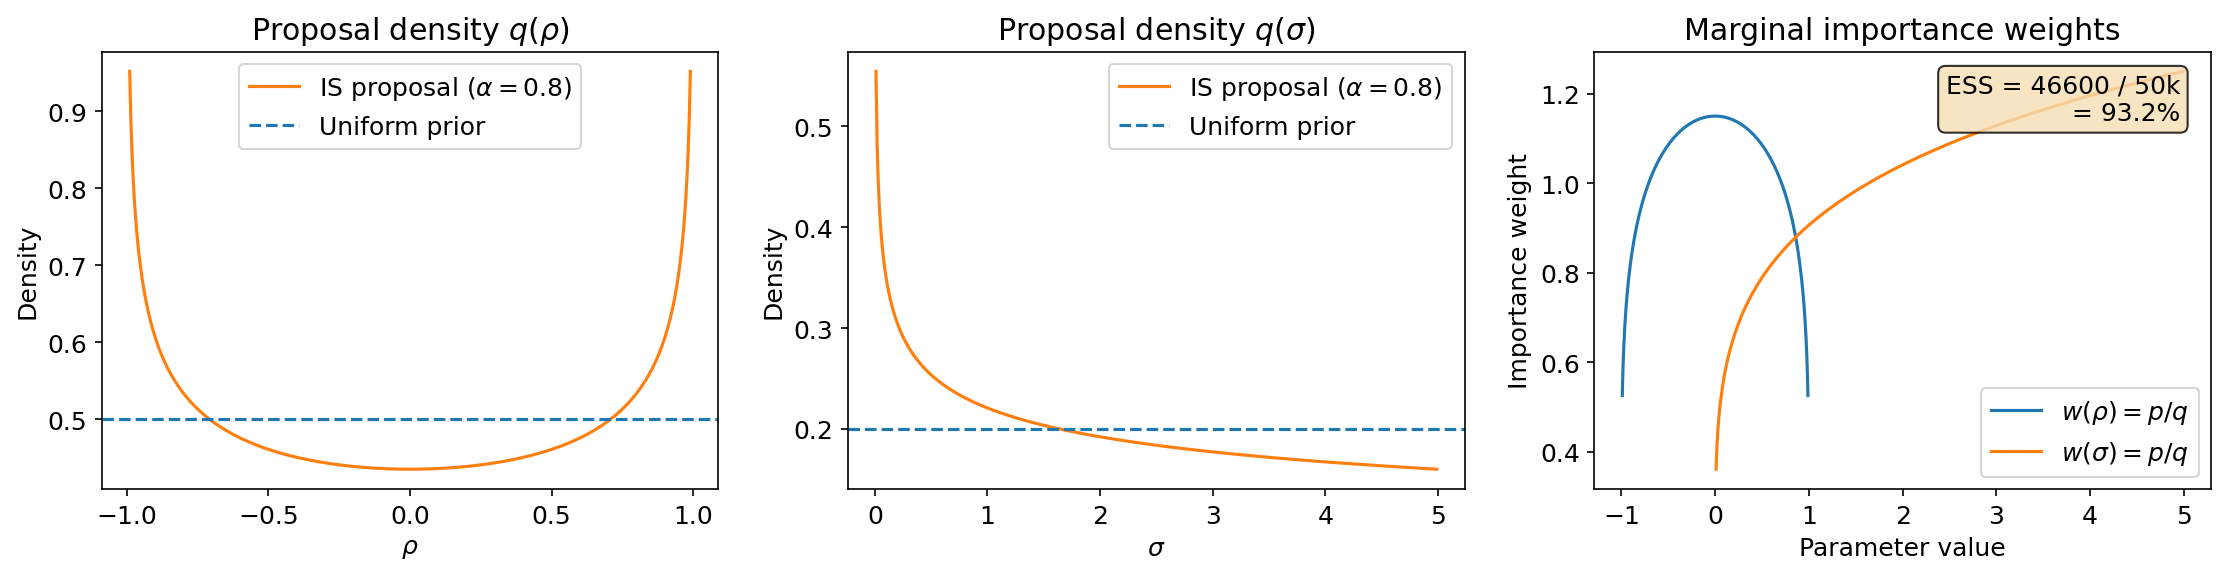

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rho_grid = np.linspace(-0.99, 0.99, 500)
sigma_grid = np.linspace(0.01, A - 0.01, 500)
rho_tilde = (rho_grid + 1) / 2
sigma_tilde = sigma_grid / A

# Proposal densities
q_rho = stats.beta.pdf(rho_tilde, ALPHA, ALPHA) / 2
q_sig = stats.beta.pdf(sigma_tilde, ALPHA, 1.0) / A
p_rho = np.ones_like(rho_grid) / 2
p_sig = np.ones_like(sigma_grid) / A

axes[0].plot(rho_grid, q_rho, 'C1', label=f'IS proposal ($\\alpha={ALPHA}$)')
axes[0].axhline(1/2, color='C0', ls='--', label='Uniform prior')
axes[0].set_xlabel(r'$\rho$'); axes[0].set_ylabel('Density')
axes[0].set_title(r'Proposal density $q(\rho)$'); axes[0].legend()

axes[1].plot(sigma_grid, q_sig, 'C1', label=f'IS proposal ($\\alpha={ALPHA}$)')
axes[1].axhline(1/A, color='C0', ls='--', label='Uniform prior')
axes[1].set_xlabel(r'$\sigma$'); axes[1].set_ylabel('Density')
axes[1].set_title(r'Proposal density $q(\sigma)$'); axes[1].legend()

# Weight distribution
w_rho = p_rho / q_rho
w_sig = p_sig / q_sig
axes[2].plot(rho_grid, w_rho, label=r'$w(\rho) = p/q$')
axes[2].plot(sigma_grid, w_sig, label=r'$w(\sigma) = p/q$')
axes[2].set_xlabel('Parameter value'); axes[2].set_ylabel('Importance weight')
axes[2].set_title('Marginal importance weights'); axes[2].legend()

# ESS
np.random.seed(0)
_, _, w_sample = sample_is(50000)
w_np = w_sample.numpy()
ess = (w_np.sum()**2) / (w_np**2).sum()
axes[2].text(0.95, 0.95, f'ESS = {ess:.0f} / 50k\n= {ess/50000:.1%}',
             transform=axes[2].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout(); plt.show()

## 2. Training (5 seeds each)

In [3]:
results = {}  # {name: {'models': [...], 'histories': [...]}}

for name, fn in [('Uniform', sample_uniform), ('IS (α=0.8)', sample_is)]:
    print(f"\n=== {name} ===")
    models, histories = [], []
    for seed in range(N_SEEDS):
        m = AR1Estimator()
        m, h = train(m, fn, n_epochs=N_EPOCHS, n_batches=N_BATCHES, lr=LR,
                     seed=seed, test_set=test_set, verbose=False,
                     normalize_weights=False)
        models.append(m)
        histories.append(h)
        print(f"  Seed {seed}: final test MSE = {h[-1]:.4f}")
    results[name] = {'models': models, 'histories': histories}
    arr = np.array(histories)
    print(f"  Mean ± std final MSE: {arr[:,-1].mean():.4f} ± {arr[:,-1].std():.4f}")


=== Uniform ===
  Seed 0: final test MSE = 0.0363
  Seed 1: final test MSE = 0.0372
  Seed 2: final test MSE = 0.0360
  Seed 3: final test MSE = 0.0348
  Seed 4: final test MSE = 0.0346
  Mean ± std final MSE: 0.0358 ± 0.0010

=== IS (α=0.8) ===
  Seed 0: final test MSE = 0.0396
  Seed 1: final test MSE = 0.0357
  Seed 2: final test MSE = 0.0351
  Seed 3: final test MSE = 0.0353
  Seed 4: final test MSE = 0.0365
  Mean ± std final MSE: 0.0364 ± 0.0016


## 3. Convergence Curves

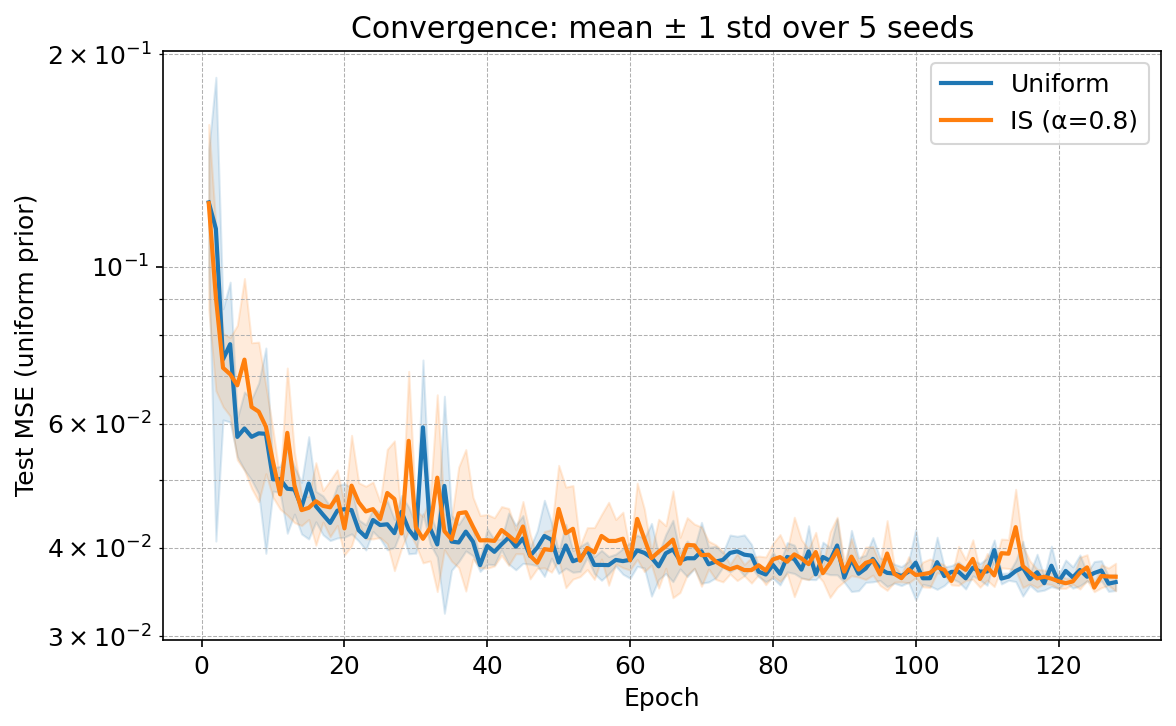

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
colours = {'Uniform': 'C0', 'IS (α=0.8)': 'C1'}

for name, res in results.items():
    arr = np.array(res['histories'])
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    epochs = np.arange(1, len(mean) + 1)
    ax.plot(epochs, mean, color=colours[name], label=name, linewidth=2)
    ax.fill_between(epochs, mean - std, mean + std, color=colours[name], alpha=0.15)

ax.set_yscale('log')
ax.set_xlabel('Epoch'); ax.set_ylabel('Test MSE (uniform prior)')
ax.set_title(f'Convergence: mean ± 1 std over {N_SEEDS} seeds')
ax.legend(fontsize=12); ax.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout(); plt.show()

## 4. Overall MSE and Scatter Plots

Using the best seed from each method (lowest final test MSE).

Method                Seed     MSE(ρ)     MSE(σ)      Total
---------------------------------------------------------
Uniform                  0     0.0127     0.0599     0.0726
Uniform                  1     0.0137     0.0607     0.0744
Uniform                  2     0.0127     0.0593     0.0720
Uniform                  3     0.0127     0.0568     0.0696
Uniform                  4     0.0133     0.0560     0.0693 *
  mean±std                                       0.0358±0.0010

IS (α=0.8)               0     0.0127     0.0664     0.0791
IS (α=0.8)               1     0.0123     0.0590     0.0713
IS (α=0.8)               2     0.0128     0.0574     0.0702 *
IS (α=0.8)               3     0.0129     0.0578     0.0707
IS (α=0.8)               4     0.0133     0.0596     0.0729
  mean±std                                       0.0364±0.0016



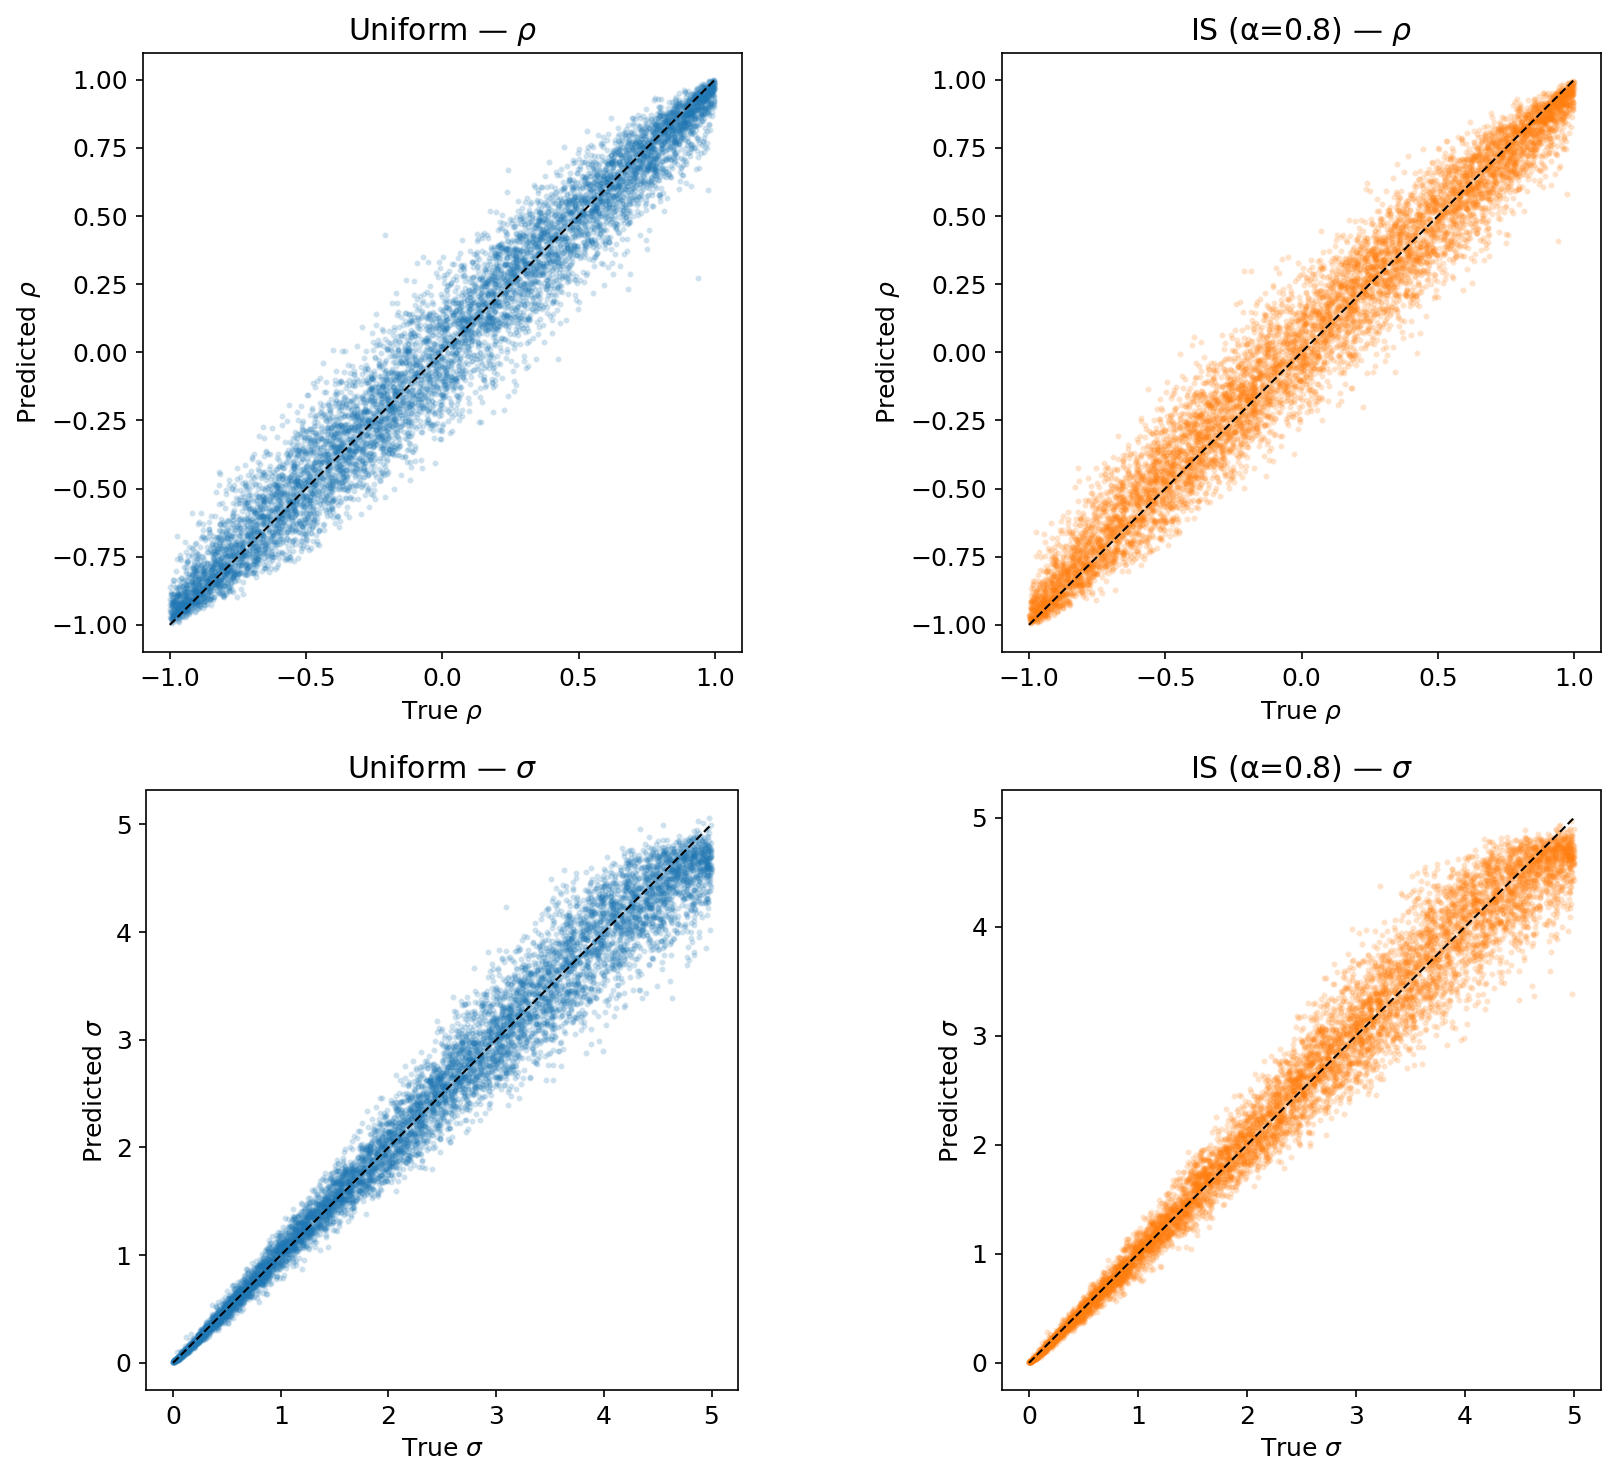

In [5]:
# Select best model per method
theta_true = test_set[0].numpy()
best = {}

for name, res in results.items():
    final_losses = [h[-1] for h in res['histories']]
    best_idx = int(np.argmin(final_losses))
    model = res['models'][best_idx]
    model.eval()
    with torch.no_grad():
        d = next(model.parameters()).device
        pred = model(test_set[1].to(d)).cpu().numpy()
    best[name] = {'model': model, 'pred': pred, 'seed': best_idx}

# MSE table (all seeds + best)
print(f"{'Method':20s} {'Seed':>5s} {'MSE(ρ)':>10s} {'MSE(σ)':>10s} {'Total':>10s}")
print('-' * 57)
for name, res in results.items():
    for i, h in enumerate(res['histories']):
        m = res['models'][i]; m.eval()
        with torch.no_grad():
            p = m(test_set[1].to(next(m.parameters()).device)).cpu().numpy()
        mr = np.mean((p[:, 0] - theta_true[:, 0])**2)
        ms = np.mean((p[:, 1] - theta_true[:, 1])**2)
        marker = ' *' if i == best[name]['seed'] else ''
        print(f"{name:20s} {i:5d} {mr:10.4f} {ms:10.4f} {mr+ms:10.4f}{marker}")
    # Mean ± std
    arr = np.array(res['histories'])
    print(f"{'  mean±std':20s} {'':>5s} {'':>10s} {'':>10s} "
          f"{arr[:,-1].mean():.4f}±{arr[:,-1].std():.4f}")
    print()

# --- Scatter plots ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for col, (name, b) in enumerate(best.items()):
    pred = b['pred']
    c = colours[name]

    # rho
    axes[0, col].scatter(theta_true[:, 0], pred[:, 0], alpha=0.15, s=4, c=c)
    axes[0, col].plot([-1, 1], [-1, 1], 'k--', linewidth=1)
    axes[0, col].set_xlabel(r'True $\rho$'); axes[0, col].set_ylabel(r'Predicted $\rho$')
    axes[0, col].set_title(f'{name} — ' + r'$\rho$')
    axes[0, col].set_aspect('equal')

    # sigma
    axes[1, col].scatter(theta_true[:, 1], pred[:, 1], alpha=0.15, s=4, c=c)
    axes[1, col].plot([0, A], [0, A], 'k--', linewidth=1)
    axes[1, col].set_xlabel(r'True $\sigma$'); axes[1, col].set_ylabel(r'Predicted $\sigma$')
    axes[1, col].set_title(f'{name} — ' + r'$\sigma$')
    axes[1, col].set_aspect('equal')

plt.tight_layout(); plt.show()

## 5. Binned MSE Analysis

The key diagnostic: how does estimation quality vary across the parameter space? We bin the test set by true $\rho$ and by true $\sigma$ and compute MSE within each bin.

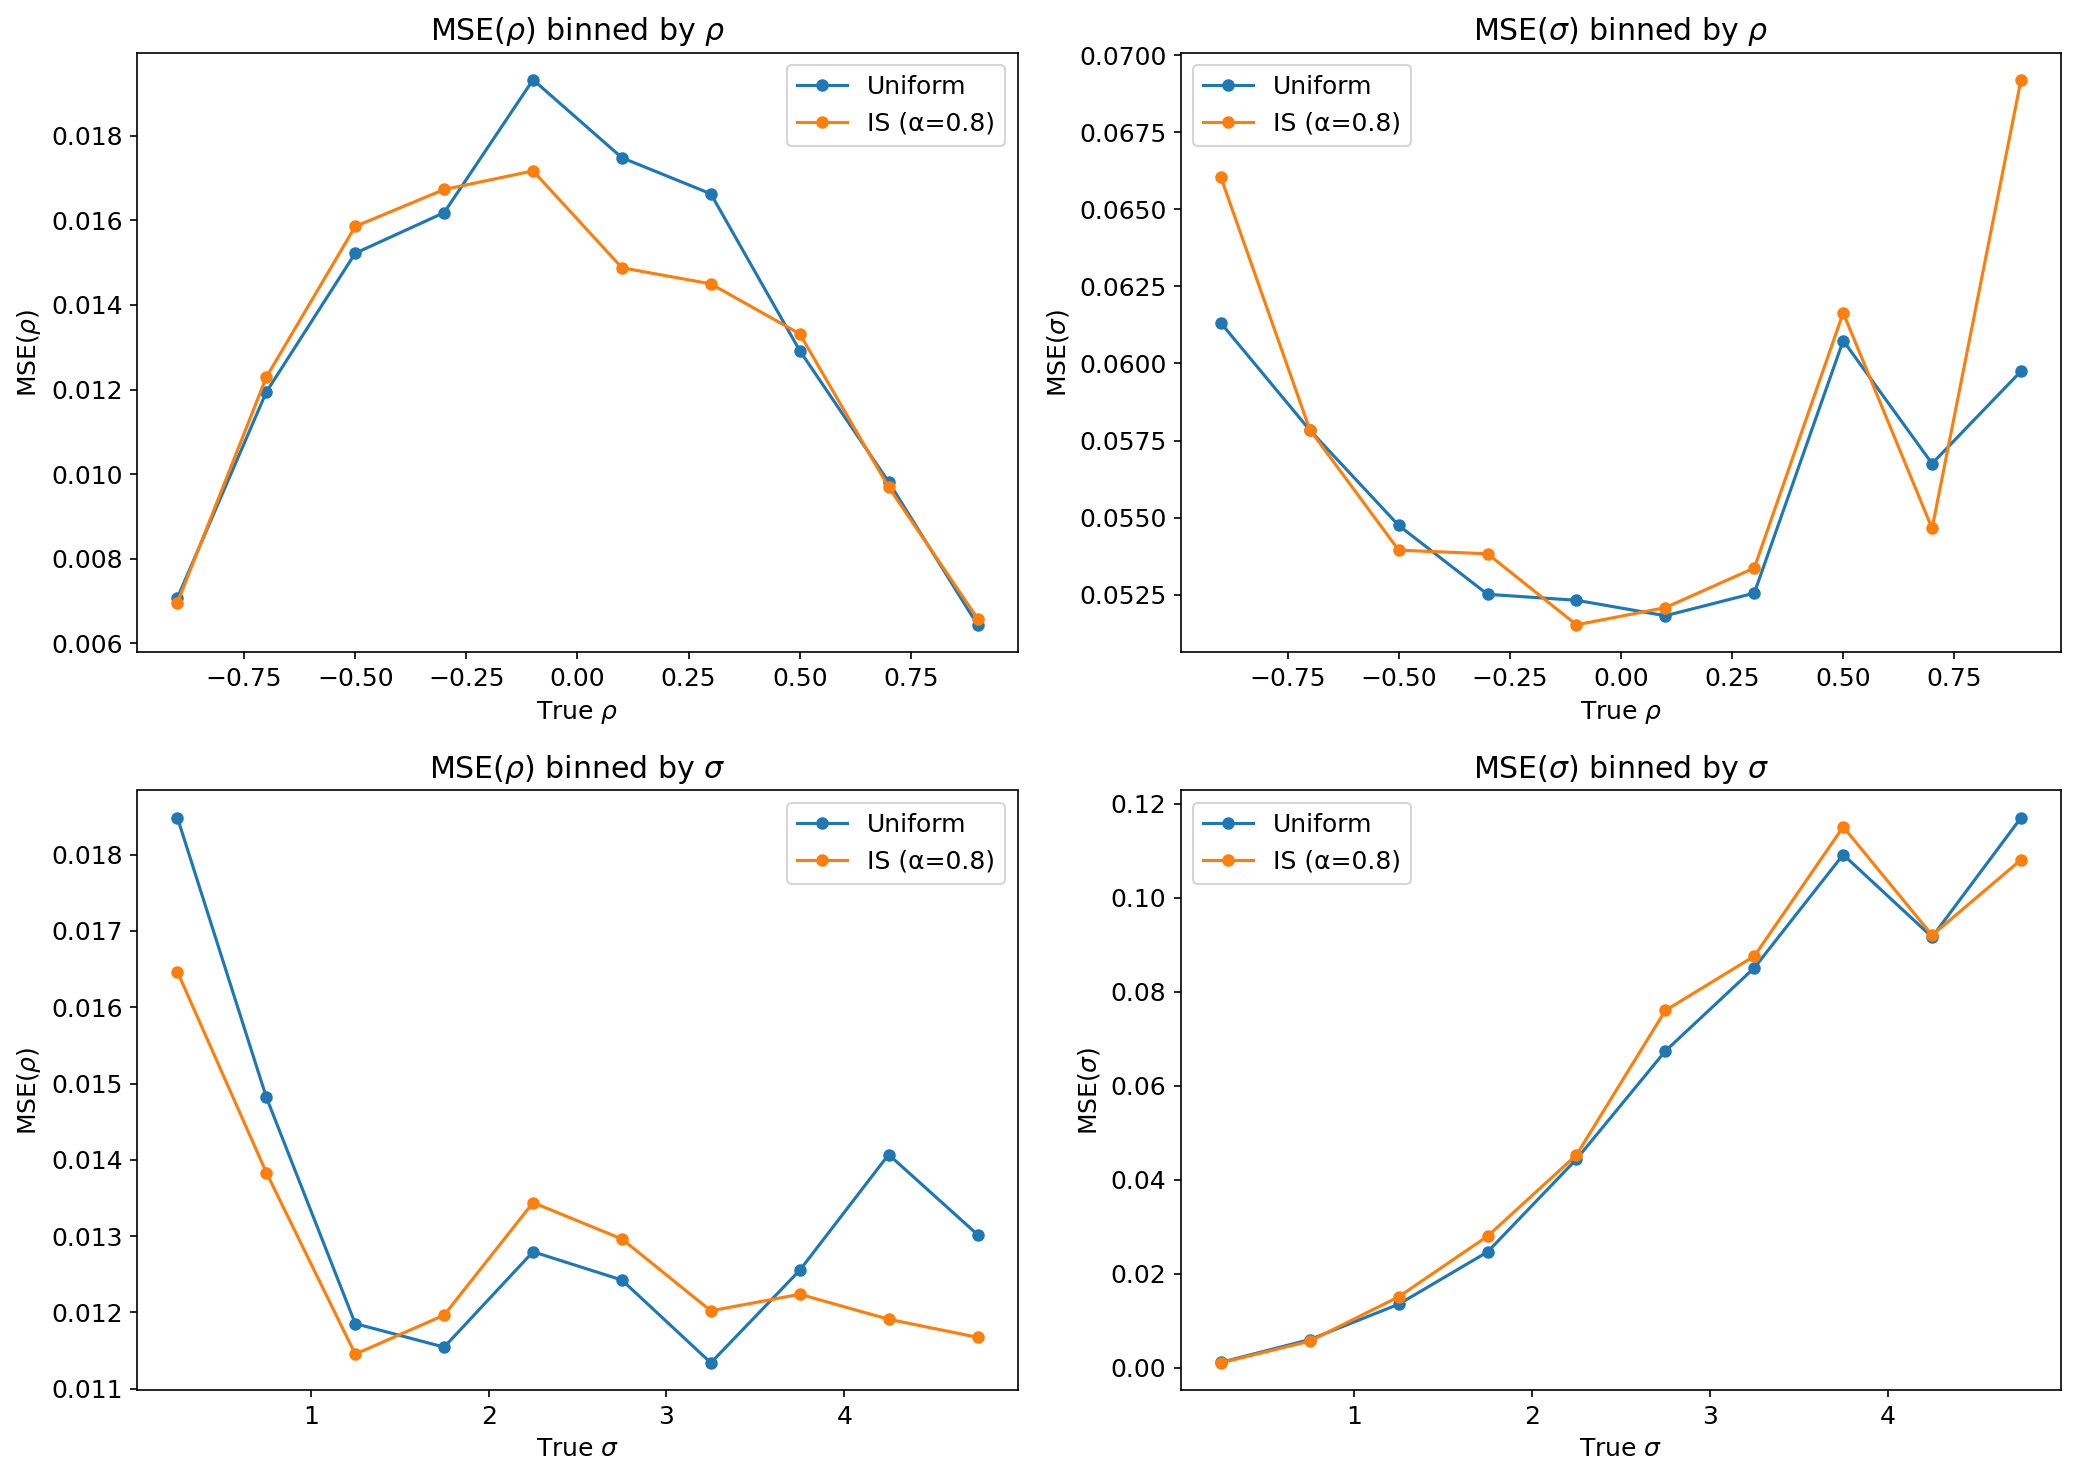

In [6]:
n_bins = 10

def compute_binned_mse(pred, true, bin_param_idx, bin_range, n_bins=10):
    """Returns (centres, mse_rho, mse_sigma) binned by the specified parameter."""
    edges = np.linspace(bin_range[0], bin_range[1], n_bins + 1)
    centres = (edges[:-1] + edges[1:]) / 2
    mse_rho = np.zeros(n_bins)
    mse_sig = np.zeros(n_bins)
    for b in range(n_bins):
        mask = (true[:, bin_param_idx] >= edges[b]) & (true[:, bin_param_idx] < edges[b+1])
        if mask.sum() > 0:
            mse_rho[b] = np.mean((pred[mask, 0] - true[mask, 0])**2)
            mse_sig[b] = np.mean((pred[mask, 1] - true[mask, 1])**2)
    return centres, mse_rho, mse_sig

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Row 0: binned by rho
for name, b in best.items():
    c, mse_r, mse_s = compute_binned_mse(b['pred'], theta_true, 0, (-1, 1))
    axes[0, 0].plot(c, mse_r, 'o-', label=name, color=colours[name], markersize=5)
    axes[0, 1].plot(c, mse_s, 'o-', label=name, color=colours[name], markersize=5)

axes[0, 0].set_xlabel(r'True $\rho$'); axes[0, 0].set_ylabel(r'MSE($\rho$)')
axes[0, 0].set_title(r'MSE($\rho$) binned by $\rho$'); axes[0, 0].legend()
axes[0, 1].set_xlabel(r'True $\rho$'); axes[0, 1].set_ylabel(r'MSE($\sigma$)')
axes[0, 1].set_title(r'MSE($\sigma$) binned by $\rho$'); axes[0, 1].legend()

# Row 1: binned by sigma
for name, b in best.items():
    c, mse_r, mse_s = compute_binned_mse(b['pred'], theta_true, 1, (0, A))
    axes[1, 0].plot(c, mse_r, 'o-', label=name, color=colours[name], markersize=5)
    axes[1, 1].plot(c, mse_s, 'o-', label=name, color=colours[name], markersize=5)

axes[1, 0].set_xlabel(r'True $\sigma$'); axes[1, 0].set_ylabel(r'MSE($\rho$)')
axes[1, 0].set_title(r'MSE($\rho$) binned by $\sigma$'); axes[1, 0].legend()
axes[1, 1].set_xlabel(r'True $\sigma$'); axes[1, 1].set_ylabel(r'MSE($\sigma$)')
axes[1, 1].set_title(r'MSE($\sigma$) binned by $\sigma$'); axes[1, 1].legend()

plt.tight_layout(); plt.show()

## 6. 2D MSE Heatmaps

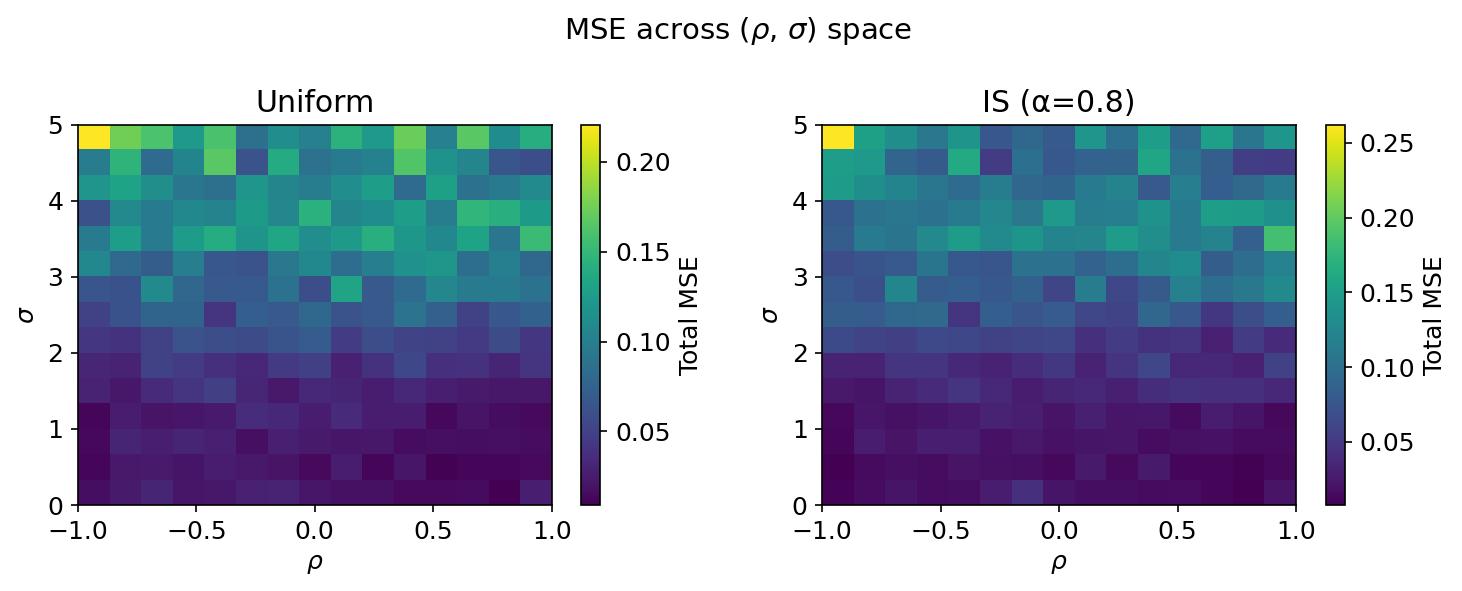

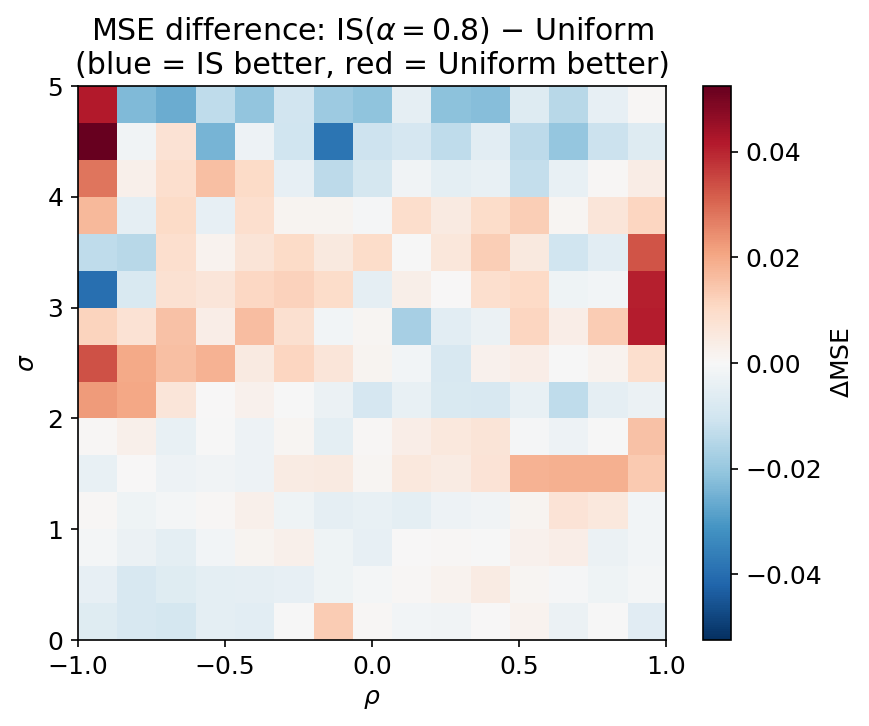

In [7]:
from sbi import heatmap_2d

preds_dict = {name: b['pred'] for name, b in best.items()}
heatmap_2d(theta_true, preds_dict, [r'$\rho$', r'$\sigma$'],
           param_ranges=[(-1, 1), (0, A)], n_bins=15)

# Also show the difference: IS minus Uniform
n_b2d = 15
rho_edges = np.linspace(-1, 1, n_b2d + 1)
sig_edges = np.linspace(0, A, n_b2d + 1)
ri = np.clip(np.digitize(theta_true[:, 0], rho_edges) - 1, 0, n_b2d - 1)
si = np.clip(np.digitize(theta_true[:, 1], sig_edges) - 1, 0, n_b2d - 1)

grids = {}
for name, pred in preds_dict.items():
    grid = np.full((n_b2d, n_b2d), np.nan)
    sq_err = ((pred - theta_true)**2).sum(axis=1)
    for r in range(n_b2d):
        for s in range(n_b2d):
            mask = (ri == r) & (si == s)
            if mask.sum() > 2:
                grid[s, r] = np.mean(sq_err[mask])
    grids[name] = grid

diff = grids['IS (α=0.8)'] - grids['Uniform']

fig, ax = plt.subplots(figsize=(6, 5))
vmax = np.nanmax(np.abs(diff))
im = ax.imshow(diff, origin='lower', aspect='auto', extent=[-1, 1, 0, A],
               cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xlabel(r'$\rho$'); ax.set_ylabel(r'$\sigma$')
ax.set_title(r'MSE difference: IS($\alpha=0.8$) $-$ Uniform' + '\n(blue = IS better, red = Uniform better)')
plt.colorbar(im, ax=ax, label=r'$\Delta$MSE')
plt.tight_layout(); plt.show()

## 7. Loss Estimator Variance

For each trained model, we draw $K=500$ independent batches from the uniform prior and compute the MC loss estimate each time. The variance of these estimates measures how *reliably* we can evaluate the model — and reflects the gradient noise the optimizer experienced during training.

Model                  Mean MSE        Std    Var Ratio
------------------------------------------------------
Uniform                  0.0704     0.0075         1.00
IS (α=0.8)               0.0711     0.0078         1.09


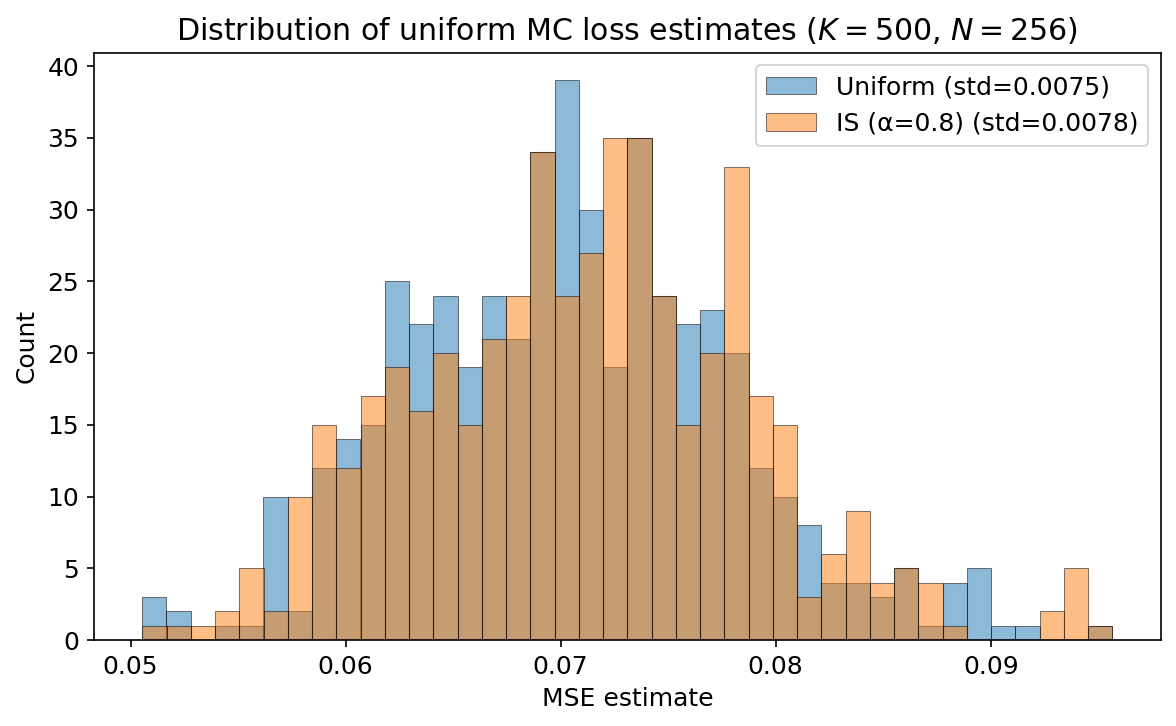

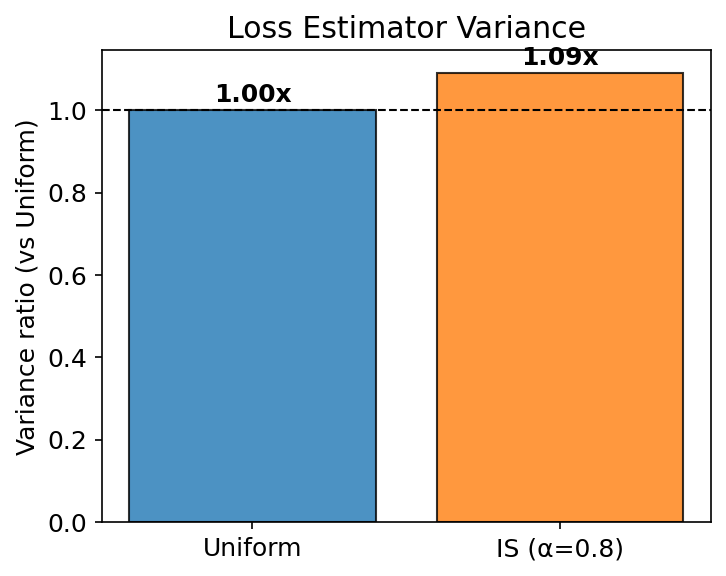

In [8]:
K = 500
N_EVAL = 256

np.random.seed(0); torch.manual_seed(0)

mc_estimates = {}

for name, b in best.items():
    model = b['model']; model.eval()
    d = next(model.parameters()).device
    estimates = []
    for _ in range(K):
        rho = torch.empty(N_EVAL, device=d).uniform_(-1, 1)
        sigma = torch.empty(N_EVAL, device=d).uniform_(0, A)
        x = simulate_ar1_batch(rho, sigma, T, device=d)
        with torch.no_grad():
            pred = model(x)
        mse = ((pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1).mean().item()
        estimates.append(mse)
    mc_estimates[name] = np.array(estimates)

# Table
ref_var = mc_estimates['Uniform'].var()
print(f"{'Model':20s} {'Mean MSE':>10s} {'Std':>10s} {'Var Ratio':>12s}")
print('-' * 54)
for name, est in mc_estimates.items():
    ratio = est.var() / ref_var
    print(f"{name:20s} {est.mean():10.4f} {est.std():10.4f} {ratio:12.2f}")

# Histograms
fig, ax = plt.subplots(figsize=(8, 5))
for name, est in mc_estimates.items():
    ax.hist(est, bins=40, alpha=0.5, color=colours[name],
            label=f"{name} (std={est.std():.4f})", edgecolor='black', linewidth=0.5)
ax.set_xlabel('MSE estimate'); ax.set_ylabel('Count')
ax.set_title(f'Distribution of uniform MC loss estimates ($K={K}$, $N={N_EVAL}$)')
ax.legend(); plt.tight_layout(); plt.show()

# Variance ratio bar chart
fig, ax = plt.subplots(figsize=(5, 4))
names = list(mc_estimates.keys())
ratios = [mc_estimates[n].var() / ref_var for n in names]
bars = ax.bar(names, ratios, color=[colours[n] for n in names],
              edgecolor='black', alpha=0.8)
ax.axhline(1.0, color='black', ls='--', lw=1)
for bar, r in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{r:.2f}x', ha='center', fontweight='bold')
ax.set_ylabel('Variance ratio (vs Uniform)')
ax.set_title('Loss Estimator Variance')
plt.tight_layout(); plt.show()